In [25]:
import pandas as pd 
import numpy as np 

from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt


In [26]:
df = pd.read_csv("knn_telecom.csv")

In [27]:
le_gender = LabelEncoder()
le_plan = LabelEncoder()

df["Gender"] = le_gender.fit_transform(df["Gender"])
df["PlanType"] = le_plan.fit_transform(df["PlanType"])


In [28]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [29]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [30]:
skf = StratifiedKFold(n_splits=3, shuffle=True,random_state=42)

k_values = range(1,8)
cv_scores = []

In [31]:
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors =k)
    scores = cross_val_score(knn, X_scaled,y, cv=skf,scoring="accuracy")
    cv_scores.append(scores.mean())

In [32]:
for k, score in zip(k_values,cv_scores):
    print("K =",k,"| Cross Validation Accuracy =", round(score, 3))

K = 1 | Cross Validation Accuracy = 0.967
K = 2 | Cross Validation Accuracy = 0.953
K = 3 | Cross Validation Accuracy = 0.973
K = 4 | Cross Validation Accuracy = 0.96
K = 5 | Cross Validation Accuracy = 0.973
K = 6 | Cross Validation Accuracy = 0.953
K = 7 | Cross Validation Accuracy = 0.953


In [33]:
best_k = k_values[np.argmax(cv_scores)]
print("\nBest K:",best_k)


Best K: 3


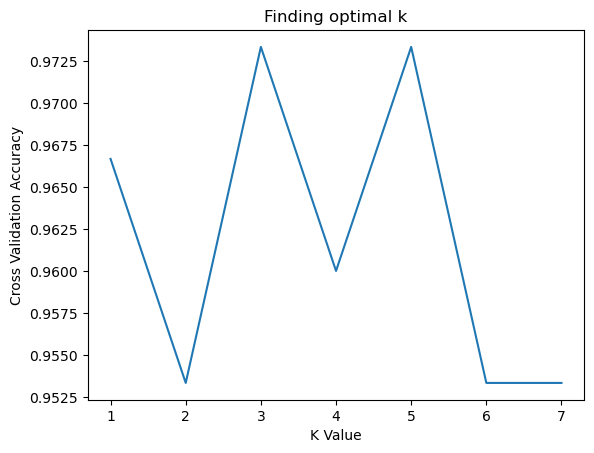

In [37]:
plt.plot(k_values, cv_scores)
plt.xlabel("K Value")
plt.ylabel("Cross Validation Accuracy")
plt.title("Finding optimal k")
plt.show()